In [5]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [6]:
import pandas as pd

df = pd.read_csv("../data/Titanic-Dataset.csv")

X = df.drop(columns=["Survived"])
y = df["Survived"]

In [7]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical:", list(numeric_features))
print("Categorical:", list(categorical_features))

Numerical: ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [9]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
model = rf_pipeline.named_steps["model"]

In [13]:
model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
def get_original_feature(transformed_name):
    name = transformed_name.split("__", 1)[1]

    for col in categorical_features:
        if name == col or name.startswith(col + "_"):
            return col

    return name


feature_importance["original_feature"] = (
    feature_importance["feature"].apply(get_original_feature)
)

original_importance = (
    feature_importance
    .groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

original_importance

,original_feature,importance
4,Name,0.238578
10,Ticket,0.238574
8,Sex,0.199945
1,Cabin,0.083260
3,Fare,0.061197
0,Age,0.047272
6,PassengerId,0.038999
7,Pclass,0.034028
2,Embarked,0.022185
9,SibSp,0.018380


In [15]:
importances = model.feature_importances_

importances

array([0.03899917, 0.03402815, 0.04727198, ..., 0.00724004, 0.00425114,
       0.01069374], shape=(1421,))

In [16]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

feature_names

array(['num__PassengerId', 'num__Pclass', 'num__Age', ...,
       'cat__Embarked_C', 'cat__Embarked_Q', 'cat__Embarked_S'],
      shape=(1421,), dtype=object)

In [23]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})



In [24]:

def get_original_feature(transformed_name):
    name = transformed_name.split("__", 1)[1]

    for col in categorical_features:
        if name == col or name.startswith(col + "_"):
            return col

    return name


feature_importance["original_feature"] = (
    feature_importance["feature"].apply(get_original_feature)
)

original_importance = (
    feature_importance
    .groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

original_importance

,original_feature,importance
4,Name,0.238578
10,Ticket,0.238574
8,Sex,0.199945
1,Cabin,0.083260
3,Fare,0.061197
0,Age,0.047272
6,PassengerId,0.038999
7,Pclass,0.034028
2,Embarked,0.022185
9,SibSp,0.018380


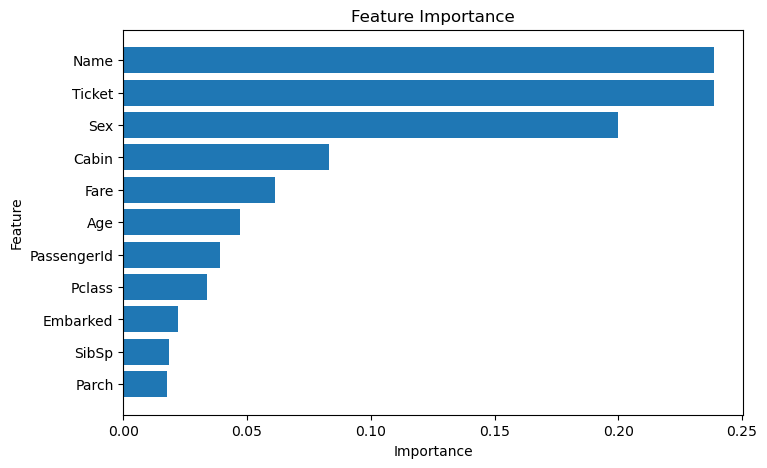

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    original_importance["original_feature"],
    original_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [27]:
top_features = original_importance.head(3)["original_feature"].tolist()

print(
    f"The model relied most on {top_features[0]}, "
    f"{top_features[1]}, and {top_features[2]}."
)

The model relied most on Name, Ticket, and Sex.


In [32]:
top_3_features = original_importance.head(3)
top_3_features = top_3_features.copy()

top_3_features["importance_percent"] = (
    top_3_features["importance"] * 100
)

top_3_features

,original_feature,importance,importance_percent
4,Name,0.238578,23.857780
10,Ticket,0.238574,23.857404
8,Sex,0.199945,19.994463


In [33]:
for _, row in top_3_features.iterrows():
    print(
        f"{row['original_feature']} contributed "
        f"{row['importance_percent']:.1f}% of the model's feature importance."
    )

Name contributed 23.9% of the model's feature importance.
Ticket contributed 23.9% of the model's feature importance.
Sex contributed 20.0% of the model's feature importance.


In [36]:
unique_percent = (X.nunique() / len(X)) * 100

id_like_cols = unique_percent[unique_percent > 90]

id_like_cols

PassengerId    100.0
Name           100.0
dtype: float64

In [37]:
suspicious_important_features = [
    feature
    for feature in top_3_features["original_feature"]
    if feature in id_like_cols.index
]

suspicious_important_features



['Name']

In [38]:
explanation_summary = {
    "top_features": list(top_3_features["original_feature"]),
    "suspicious_important_features": suspicious_important_features
}

explanation_summary

{'top_features': ['Name', 'Ticket', 'Sex'],
 'suspicious_important_features': ['Name']}

In [39]:
for feature in explanation_summary["top_features"]:
    if feature in explanation_summary["suspicious_important_features"]:
        print(f"{feature}: important, but potentially ID-like.")
    else:
        print(f"{feature}: important to the model.")

Name: important, but potentially ID-like.
Ticket: important to the model.
Sex: important to the model.


In [40]:
original_importance["importance"].sum()

np.float64(1.0)

In [41]:
feature_importance_report = original_importance.reset_index(drop=True)

feature_importance_report

,original_feature,importance
0,Name,0.238578
1,Ticket,0.238574
2,Sex,0.199945
3,Cabin,0.083260
4,Fare,0.061197
5,Age,0.047272
6,PassengerId,0.038999
7,Pclass,0.034028
8,Embarked,0.022185
9,SibSp,0.018380


In [42]:
feature_importance_report.columns

Index(['original_feature', 'importance'], dtype='object')

## Feature Importance Report

This table contains the original dataset features ranked by their total importance in the Random Forest model. One-hot encoded categorical features were grouped back to their original columns.